# Module 1 Mini Project — Exploring the Titanic Passengers

**In plain English:** we have a spreadsheet listing everyone who was on the Titanic —
their age, sex, ticket class, how much they paid, and whether they survived. This
notebook plays detective with that spreadsheet: we look at what's in it, check for
gaps and weird values, draw some pictures of it, and ask one probability question
(did your ticket class affect your odds of survival?). At the end there's a plain-English
summary of what we found.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load the data and get a first look
`shape` tells us rows x columns, `dtypes` tells us what kind of data is in each
column (numbers vs text), `.info()` gives a compact summary, and `.describe()`
gives quick statistics for the numeric columns.

In [2]:
df = pd.read_csv("../data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Shape (rows, columns):", df.shape)
df.dtypes

Shape (rows, columns): (891, 12)


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2. Typical values — mean, median, variance, standard deviation
For each numeric column: the **mean** (average), **median** (the middle value),
**variance** (how spread out the values are), and **standard deviation** (the
"typical" distance from the average — the square root of variance).

In [6]:
numeric_cols = df.select_dtypes(include=np.number).drop(columns=["PassengerId"]).columns
summary_stats = df[numeric_cols].agg(["mean", "median", "var", "std"]).T
summary_stats

,mean,median,var,std
Survived,0.383838,0.0000,0.236772,0.486592
Pclass,2.308642,3.0000,0.699015,0.836071
Age,29.699118,28.0000,211.019125,14.526497
SibSp,0.523008,0.0000,1.216043,1.102743
Parch,0.381594,0.0000,0.649728,0.806057
Fare,32.204208,14.4542,2469.436846,49.693429


## 3. Missing values and obvious outliers
No fixing yet — the task is just to notice and report what's missing or unusual.

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0")

,missing_count,missing_pct
Age,177,19.9
Cabin,687,77.1
Embarked,2,0.2


`Cabin` is missing for the large majority of passengers, `Age` is missing for
about a fifth of them, and `Embarked` (which port they boarded at) is only
missing for 2 people. Now let's check for outliers — unusually extreme values —
in the two main numeric columns people care about: `Age` and `Fare`.

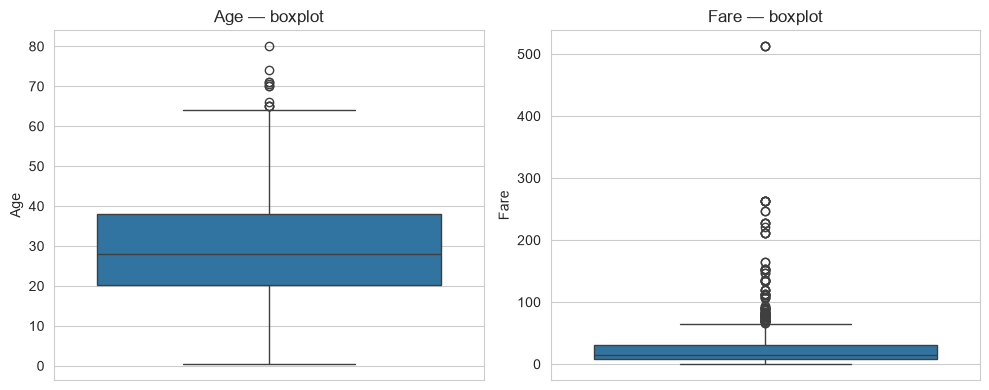

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df["Age"], ax=axes[0])
axes[0].set_title("Age — boxplot")
sns.boxplot(y=df["Fare"], ax=axes[1])
axes[1].set_title("Fare — boxplot")
plt.tight_layout()
plt.show()

In [9]:
print("Most expensive fares paid:")
df.sort_values("Fare", ascending=False)[["Name", "Pclass", "Fare"]].head(5)

Most expensive fares paid:


,Name,Pclass,Fare
679,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292
258,"Ward, Miss. Anna",1,512.3292
737,"Lesurer, Mr. Gustave J",1,512.3292
88,"Fortune, Miss. Mabel Helen",1,263.0000
438,"Fortune, Mr. Mark",1,263.0000


`Fare` has a handful of very high outliers (a few passengers paid far more than
everyone else — likely first-class suites). `Age` looks much more evenly spread,
with just a few elderly outliers above ~65.

## 4. Univariate plots (one variable at a time)

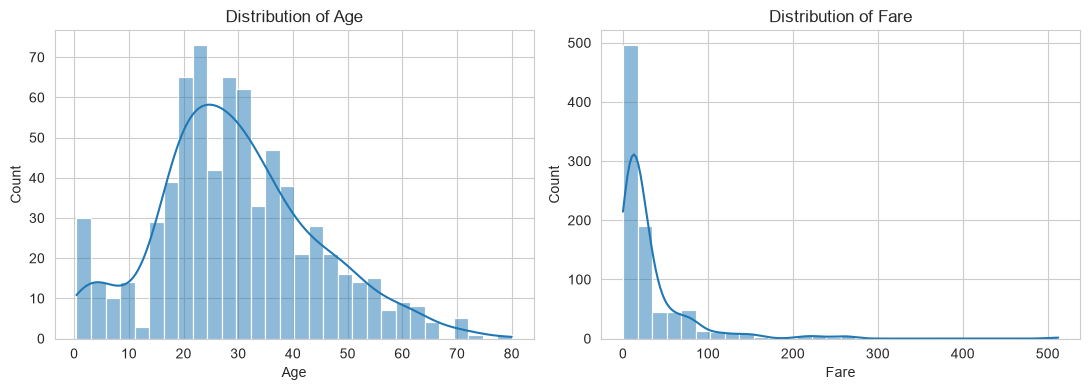

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["Age"].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Age")
sns.histplot(df["Fare"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Fare")
plt.tight_layout()
plt.show()

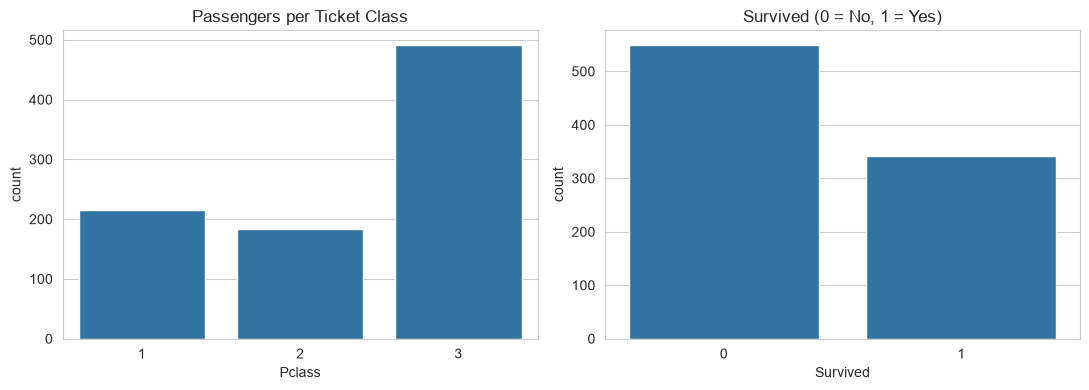

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="Pclass", data=df, ax=axes[0])
axes[0].set_title("Passengers per Ticket Class")
sns.countplot(x="Survived", data=df, ax=axes[1])
axes[1].set_title("Survived (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

## 5. Bivariate plots (two variables together)

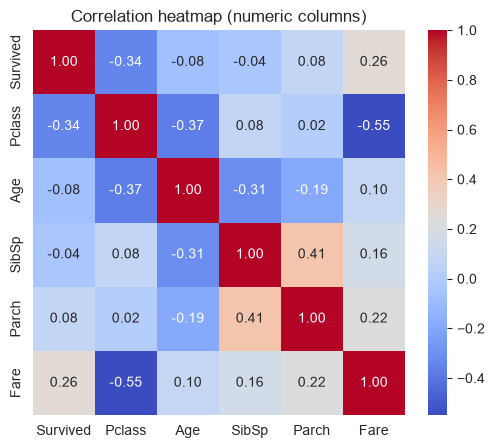

In [12]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap (numeric columns)")
plt.show()

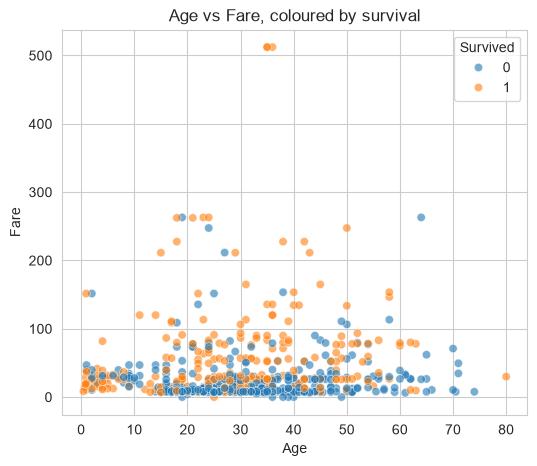

In [13]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived", alpha=0.6)
plt.title("Age vs Fare, coloured by survival")
plt.show()

## 6. Probability exercise — did ticket class affect survival odds?
This is a **conditional probability**: "given that someone was in class X, what's
the probability they survived?" — written as P(Survived | Pclass).

In [14]:
overall_survival_rate = df["Survived"].mean()
print(f"Overall probability of survival, P(Survived): {overall_survival_rate:.2%}")

survival_by_class = df.groupby("Pclass")["Survived"].mean()
print("\nProbability of survival given class, P(Survived | Pclass):")
survival_by_class

Overall probability of survival, P(Survived): 38.38%

Probability of survival given class, P(Survived | Pclass):


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

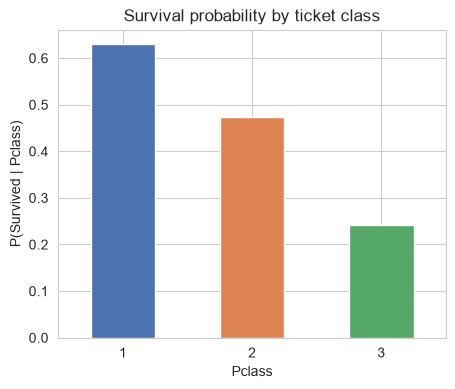

In [15]:
plt.figure(figsize=(5, 4))
survival_by_class.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylabel("P(Survived | Pclass)")
plt.title("Survival probability by ticket class")
plt.xticks(rotation=0)
plt.show()

In [16]:
survival_by_class_sex = df.groupby(["Pclass", "Sex"])["Survived"].mean()
print("Probability of survival given class AND sex, P(Survived | Pclass, Sex):")
survival_by_class_sex

Probability of survival given class AND sex, P(Survived | Pclass, Sex):


Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

## Insights (plain English)

- **891 passengers, 12 columns.** Most numbers are clean; only `Age` (~20% missing),
  `Cabin` (~77% missing), and `Embarked` (2 missing) have gaps.
- **Class mattered a lot.** 1st-class passengers survived far more often than 2nd
  or 3rd class — the gap is roughly 2-3x between the top and bottom class.
- **Sex mattered even more than class.** Splitting survival by class *and* sex
  shows women in every class survived at much higher rates than men in that
  same class — consistent with a "women and children first" evacuation pattern.
- **Fare and class are closely linked, but not identical.** Passengers who paid
  more tended to be in the better classes (a moderate negative correlation of
  about -0.55 between `Fare` and `Pclass`), so the two columns are telling a
  related but not perfectly overlapping story about wealth/status.
- **A few passengers paid extreme, outlier-level fares** — far above what
  everyone else paid — while `Age` had no similarly dramatic outliers, just a
  small number of elderly passengers.
- **Overall, only a minority of passengers survived** — the dataset is not a
  50/50 split, so raw counts alone would be misleading without looking at rates.
- **Bottom line:** on the Titanic, *where you could afford to be, and whether you
  were a woman or a man,* mattered more to your odds of survival than almost
  anything else in this data.
